In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import importlib
import optical_tweezers_function_file
import save_results_function_file   
importlib.reload(optical_tweezers_function_file)
importlib.reload(save_results_function_file)
from save_results_function_file import *
from optical_tweezers_function_file import *
plt.rcParams["animation.html"] = "jshtml"

%load_ext line_profiler

Search simulations of atom loading from MOT to lattice

In [2]:
#Find by parameters
matches = find_simulations(
    "simulation_data",
    {
        "N_atoms": 150,
        "temperature": lambda x: x < 1e-4
    }
)

for m in matches:
    print(m)

simulation_data\sim_53bc989e0d775e274f2caeaf441028bb.h5


In [3]:
# Find by date
matches = find_by_date(
    "simulation_data",
    start_date="2026-04-30T00:00:00"
)

for path, date in matches:
    print(date, path)

2026-04-30 10:33:48.992586 simulation_data\sim_53bc989e0d775e274f2caeaf441028bb.h5


Load parameters and results of the simulation

In [4]:
filepath = "simulation_data/sim_53bc989e0d775e274f2caeaf441028bb.h5"

with h5py.File(filepath, "r") as f:
    
    # --- Load results ---
    t = f["results/time"][:]
    vels_overtime = f["results/velocities"][:]
    pos_overtime = f["results/positions"][:]
    energies_overtime = f["results/energies"][:]
    idx_lost_atoms = f["results/lost_atoms"][:]
    
    # --- Load inputs (metadata) ---
    inputs = {key: json.loads(val) for key, val in f["inputs"].attrs.items()}
    
    # --- Other metadata ---
    date = f.attrs["date"]
    sim_hash = f.attrs["hash"]

print(inputs)
print(date)

{'N_atoms': 150, 'beam_positions': [0, 0], 'beam_waist': [5e-05, 5e-05], 'doppler_temperature': 4.4e-06, 'frequencies': [3.540698434791077e+24, 3.540698434791077e+24], 'laser_power': 1, 'max_t': 0.0001, 'mot_radius': 5e-05, 'polarizability': 4.451698634726281e-39, 't_points': 18182, 'temperature': 8.8e-06, 'wavelength': 5.32e-07}
2026-04-30T10:33:48.992586


# Parameters of the lattice beams

In [5]:
# Parameters 3D MOT
N_atoms = len(idx_lost_atoms)
T_D = inputs['doppler_temperature']                         #K Doppler temperature for 1S0 → 3P1 transition of Yb
T = inputs['temperature']                                   #K
radii = inputs['mot_radius']                                #m

# Parameters lattice
Re_alpha_lat = inputs['polarizability']                     #A^2s^4/kg
P_lat = inputs['laser_power']                               #W
w01, w02 = inputs['beam_waist']                             #m
wavelength_lat = inputs['wavelength']                       #m
w1, w2 = inputs['frequencies']                              #Hz
x01, x02 = inputs['beam_positions']                         #m

# Optical lattice propagation in x

In [6]:
#Variables
x = np.linspace(-5*wavelength_lat, 5*wavelength_lat, 500)                   #m
y = np.linspace(-10e-3, 10e-3, 500)                                 #m
z = np.linspace(-10e-3, 10e-3, 500)                                 #m

In [7]:
#U_x_y_z
U_x_0_0_latt = optical_dipole_trap_2_beams_rotated(x, 0, 0, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, w1, w2)   #J
latt_depth_x = np.mean(lattice_depth_2_beams_rotated(x, 0, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, 0, 0))     #J
U_0_latt_x = U_0_latt_2_beams_rotated(x, 0, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, 0, 0)                     #J

U_0_y_0_latt = optical_dipole_trap_2_beams_rotated(0, y, 0, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, w1, w2)   #J
latt_depth_y = np.mean(lattice_depth_2_beams_rotated(0, y, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, 0, 0))     #J
U_0_latt_y = U_0_latt_2_beams_rotated(0, y, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, 0, 0)                     #J

U_0_0_z_latt = optical_dipole_trap_2_beams_rotated(0, 0, z, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, w1, w2)   #J
latt_depth_z = np.mean(lattice_depth_2_beams_rotated(0, 0, z, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, 0, 0))     #J
U_0_latt_z = U_0_latt_2_beams_rotated(0, 0, z, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, 0, 0)                     #J

#I_x_y_z
I1 = gaussian_beam_rotated(x, 0, 0, P_lat, w01, wavelength_lat, z0=0)                                                 #W/m^2
I2 = gaussian_beam_rotated(x, 0, 0, P_lat, w02, wavelength_lat, z0=0)                                                 #W/m^2
I_latt_0_0_x = two_gaussian_beams_rotated(x, 0, I1, I2, w1, w2, wavelength_lat)                                           #W/m^2

I1 = gaussian_beam_rotated(0, y, 0, P_lat, w01, wavelength_lat, z0=0)                                                 #W/m^2
I2 = gaussian_beam_rotated(0, y, 0, P_lat, w02, wavelength_lat, z0=0)                                                 #W/m^2
I_latt_0_y_0 = two_gaussian_beams_rotated(0, 0, I1, I2, w1, w2, wavelength_lat)                                           #W/m^2

I1 = gaussian_beam_rotated(0, 0, z, P_lat, w01, wavelength_lat, z0=0)                                                 #W/m^2
I2 = gaussian_beam_rotated(0, 0, z, P_lat, w02, wavelength_lat, z0=0)                                                 #W/m^2
I_latt_0_0_z = two_gaussian_beams_rotated(0, 0, I1, I2, w1, w2, wavelength_lat)                                           #W/m^2

#Recoil energy
E_r = recoil_energy(m_yb, wavelength_lat)

Lattice depth: 8.541348232332773e-28 J


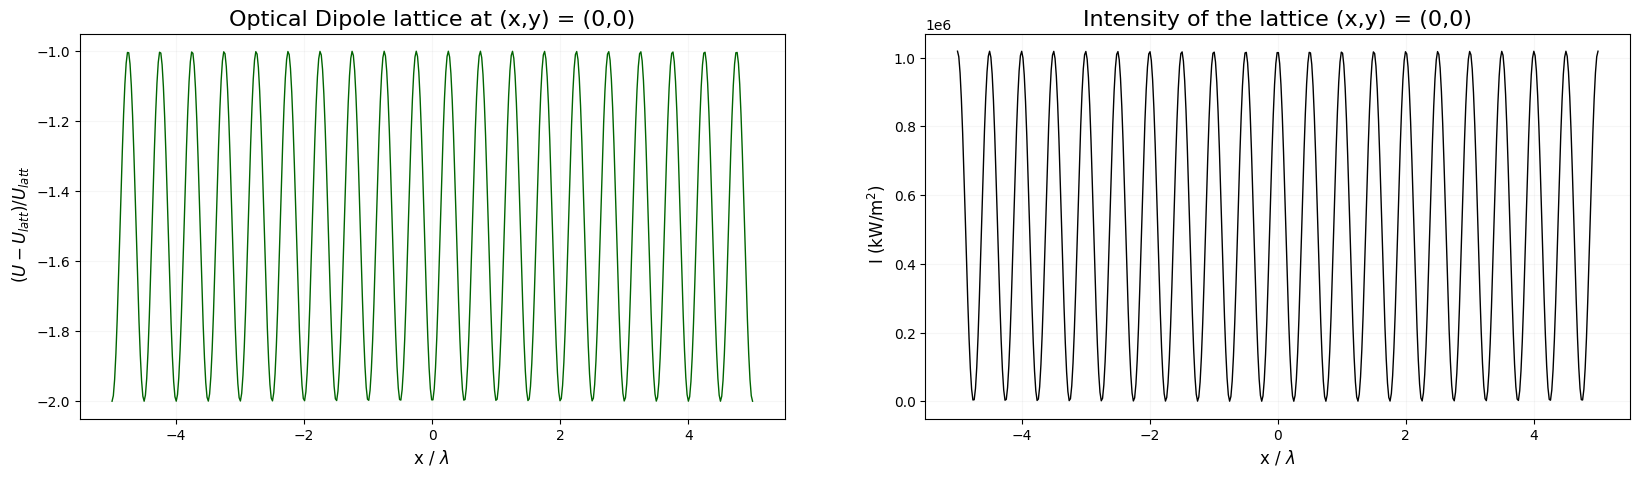

In [8]:
print('Lattice depth:', latt_depth_x, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(x/wavelength_lat, (U_x_0_0_latt-latt_depth_x)/latt_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(x/wavelength_lat, I_latt_0_0_x*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

In [9]:
idx0 = np.argmin(np.abs(x-0))
idx1 = np.argmin(np.abs(x+wavelength_lat/2))
idx2 = np.argmin(np.abs(x-wavelength_lat/2))
idx_max_1 = np.argmax(U_x_0_0_latt[idx1:idx0]) + idx1
idx_max_2 = np.argmax(U_x_0_0_latt[idx0:idx2]) + idx0
U_single = U_x_0_0_latt[idx_max_1:idx_max_2]
x_single = x[idx_max_1:idx_max_2]

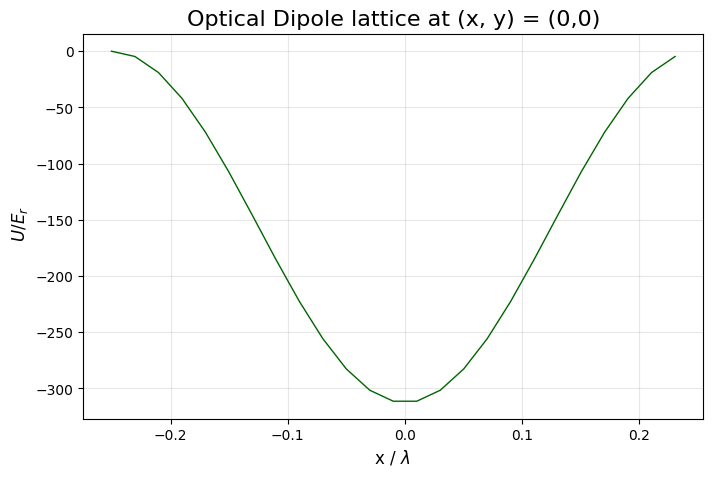

In [10]:
plt.figure(figsize=(8,5))
plt.plot(x_single/wavelength_lat, U_single/E_r,  color='darkgreen', linewidth=1, markersize = 1)
plt.title('Optical Dipole lattice at (x, y) = (0,0)', fontsize=16)
plt.xlabel(r'x / $\lambda$ ', fontsize=12)
plt.ylabel(r' $U / E_r$', fontsize=12)
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

Lattice depth: 2.6684274298837134e-30 J


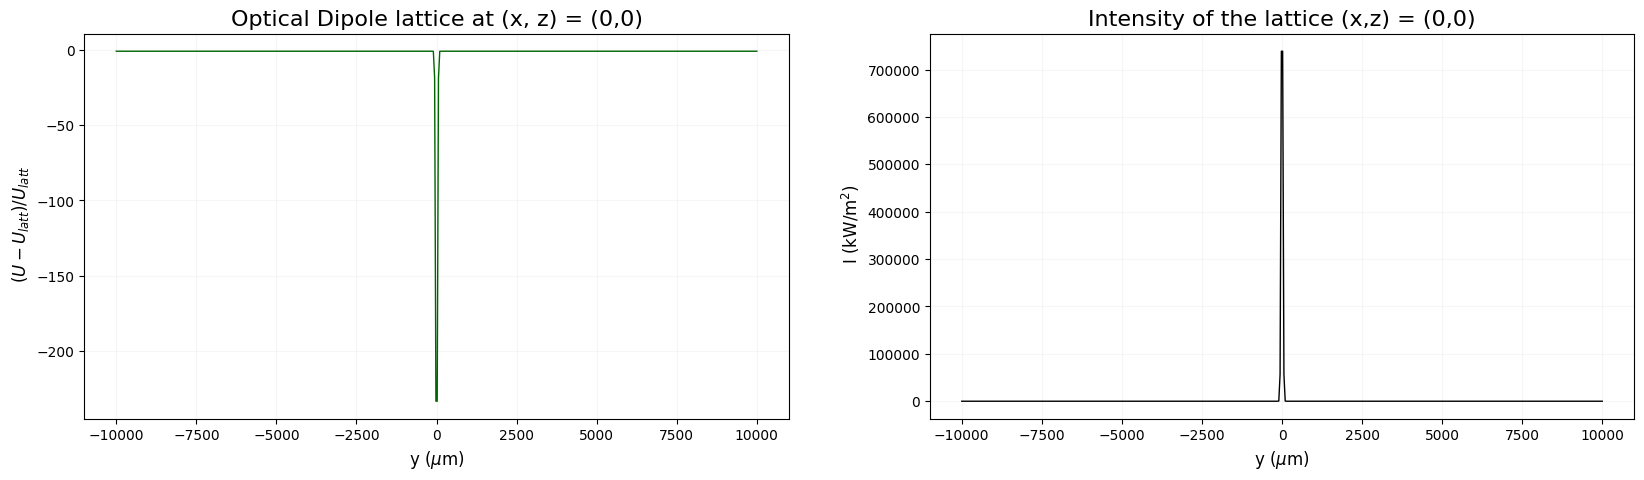

In [11]:
print('Lattice depth:', latt_depth_y, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(y*1e6, (U_0_y_0_latt-latt_depth_y)/latt_depth_y,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x, z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'y ($\mu$m)', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(y*1e6, I_latt_0_y_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'y ($\mu$m) ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

Lattice depth: 2.6684274298837134e-30 J


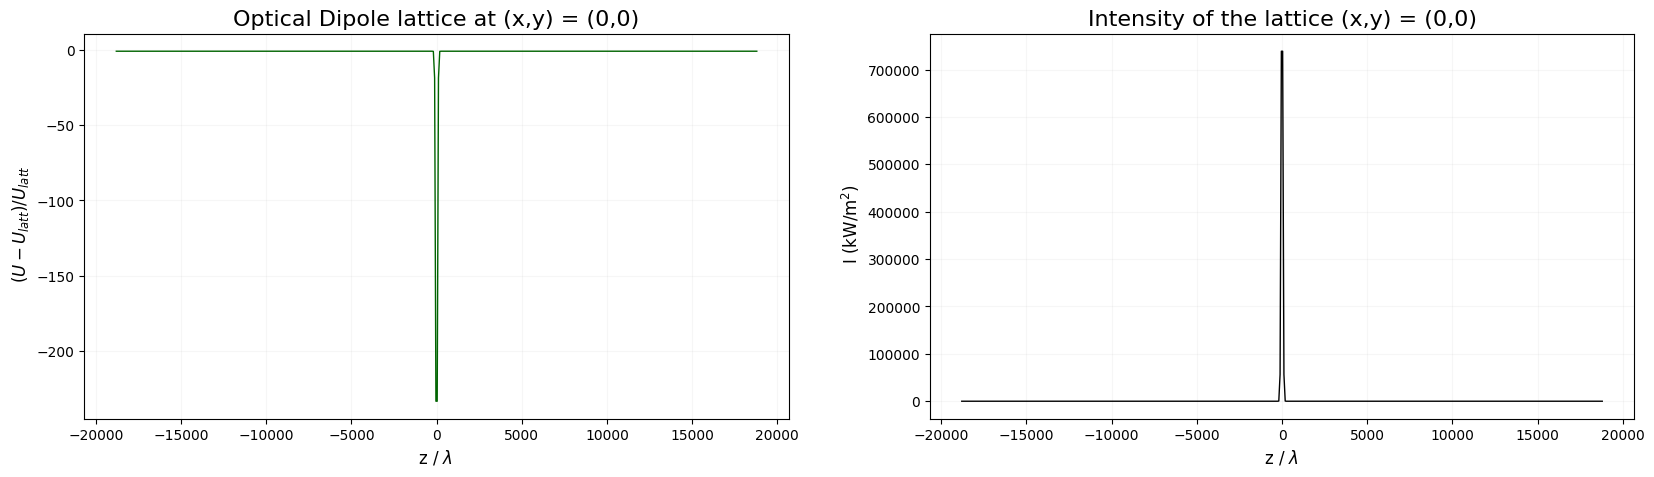

In [12]:
print('Lattice depth:', latt_depth_z, 'J')
fig, axes = plt.subplots(1, 2, figsize=(20,5))
axes[0].plot(z/wavelength_lat, (U_0_0_z_latt-latt_depth_z)/latt_depth_z,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical Dipole lattice at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $(U-U_{latt})/U_{latt}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(z/wavelength_lat, I_latt_0_0_z*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the lattice (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

# Optical tweezer

In [13]:
#Parameters
Re_alpha_tw = au_to_SI(359)                                           #A^2s^4/kg
P_tw = 1                                                              #W
w0 = 650e-9                                                           #m
wavelength_tw = 485e-9                                                #m
w_tw= 2*np.pi*nm_to_Hz(wavelength_tw)                                 #Hz
#Variables
z = np.linspace(-30*wavelength_tw, 30*wavelength_tw, 500)             #m
x = np.linspace(-30*wavelength_tw, 30*wavelength_tw, 500)             #m
y = np.linspace(-30*wavelength_tw, 30*wavelength_tw, 500)             #m

In [14]:
#U_x_y_z
U_0_0_z_tw = optical_dipole_trap_1_beam(0, 0, z, Re_alpha_tw, P_tw, w0, wavelength_tw, 0)               #J
pot_depth_z = potential_depth_1_beam(Re_alpha_tw, P_tw, w0)                                             #J

U_x_0_0_tw = optical_dipole_trap_1_beam(x, 0, 0, Re_alpha_tw, P_tw, w0, wavelength_tw, 0)               #J
pot_depth_x = potential_depth_1_beam(Re_alpha_tw, P_tw, w0)                                             #J

U_0_y_0_tw = optical_dipole_trap_1_beam(0, y, 0, Re_alpha_tw, P_tw, w0, wavelength_tw, 0)               #J
pot_depth_y = potential_depth_1_beam(Re_alpha_tw, P_tw, w0)                                             #J
#I_x_y_z
I_tw_0_0_z = gaussian_beam(0, 0, z, P_tw, w0, wavelength_tw, z0=0)                                      #W/m^2

I_tw_x_0_0 = gaussian_beam(x, 0, 0, P_tw, w0, wavelength_tw, z0=0)                                      #W/m^2

I_tw_0_y_0 = gaussian_beam(0, y, 0, P_tw, w0, wavelength_tw, z0=0)                                      #W/m^2

#Recoil energy
E_r = recoil_energy(m_yb, wavelength_tw)

### z-dependence

Lattice depth: 1.68000440977578e-24 J


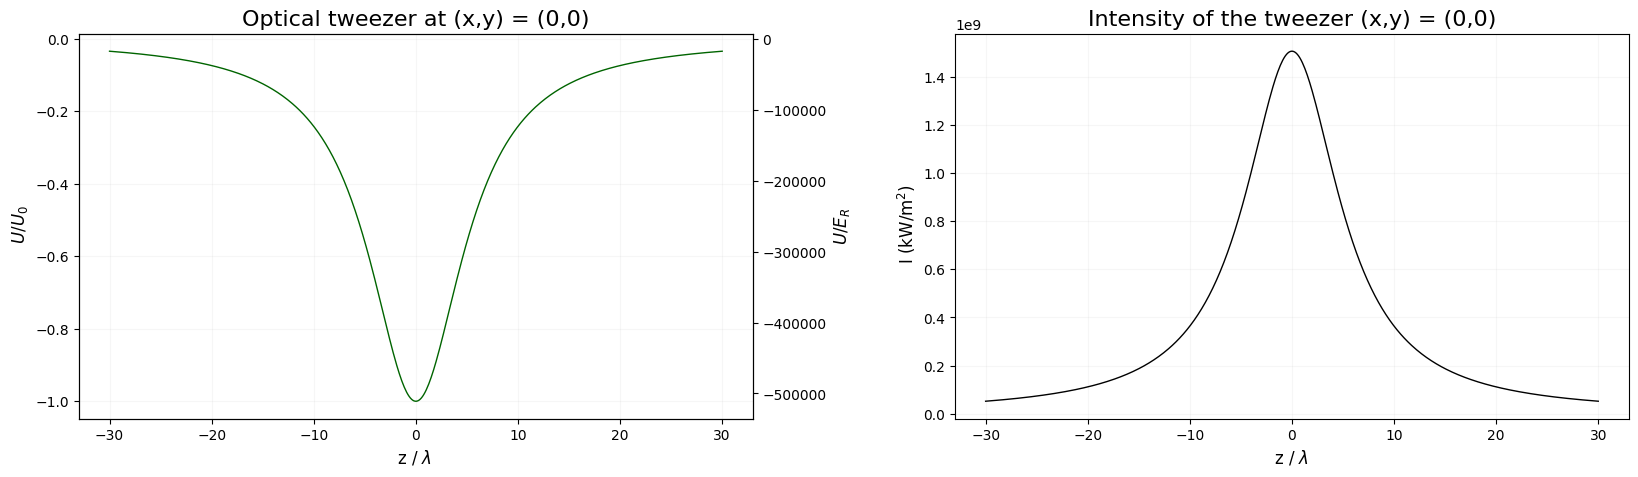

In [15]:
print('Lattice depth:', pot_depth_z, 'J')
U0_over_ER = pot_depth_z / E_r   # U0 / E_R
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(z/wavelength_tw, U_0_0_z_tw/pot_depth_z,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical tweezer at (x,y) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $U/U_{0}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

# secondary y-axis
ax2 = axes[0].twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes[0].get_ylim()
ax2.set_ylim(ymin *U0_over_ER , ymax * U0_over_ER) #U/E_r = U/U_0*u_0/E_r

axes[1].plot(z/wavelength_tw, I_tw_0_0_z*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the tweezer (x,y) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'z / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

### x-dependence

Lattice depth: 1.68000440977578e-24 J


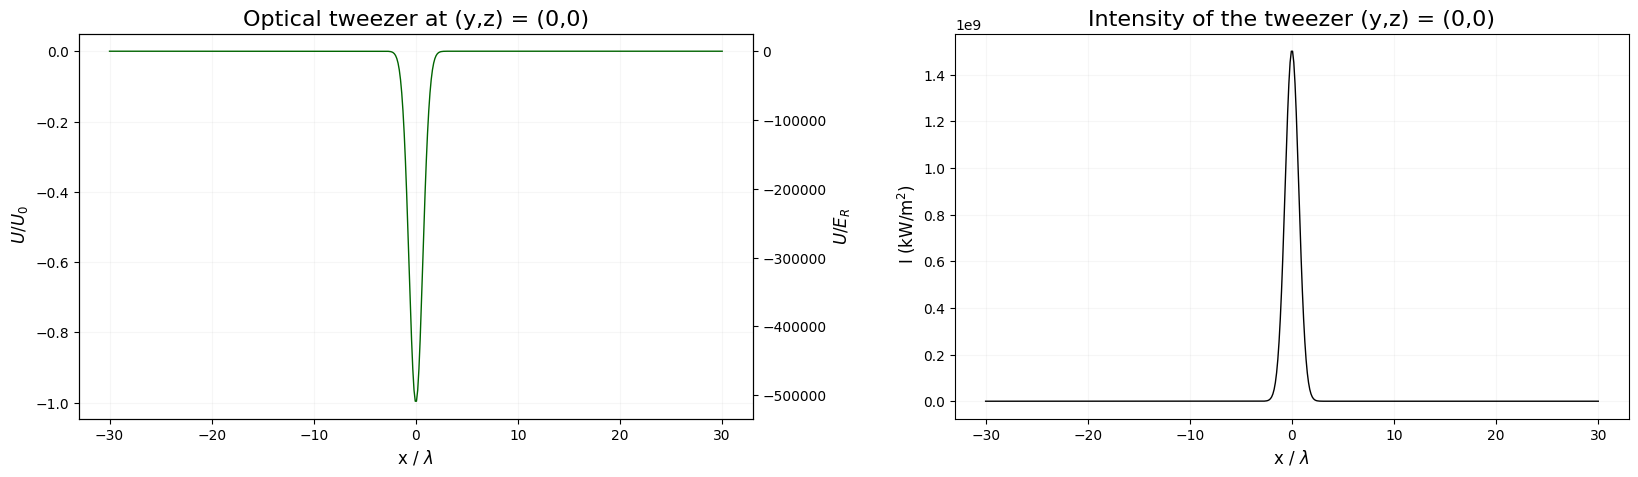

In [16]:
print('Lattice depth:', pot_depth_x, 'J')
U0_over_ER = pot_depth_x / E_r   # U0 / E_R
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(x/wavelength_tw, U_x_0_0_tw/pot_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical tweezer at (y,z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $U/U_{0}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

# secondary y-axis
ax2 = axes[0].twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes[0].get_ylim()
ax2.set_ylim(ymin *U0_over_ER , ymax * U0_over_ER) #U/E_r = U/U_0*u_0/E_r

axes[1].plot(x/wavelength_tw, I_tw_x_0_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the tweezer (y,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'x / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

### y-dependence

Lattice depth: 1.68000440977578e-24 J


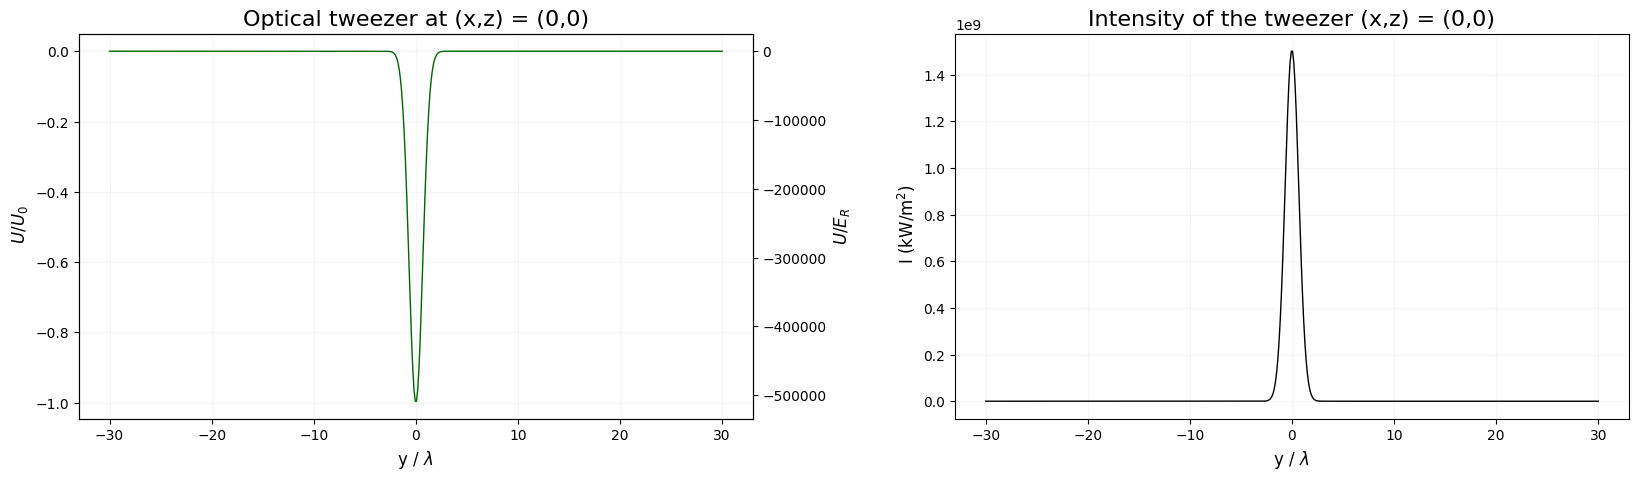

In [17]:
print('Lattice depth:', pot_depth_y, 'J')
U0_over_ER = pot_depth_y / E_r   # U0 / E_R
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)
axes[0].plot(y/wavelength_tw, U_0_y_0_tw/pot_depth_x,  color='darkgreen', linewidth=1, markersize = 1)
axes[0].set_title('Optical tweezer at (x,z) = (0,0)', fontsize=16)
axes[0].set_xlabel(r'y / $\lambda$ ', fontsize=12)
axes[0].set_ylabel(r' $U/U_{0}$', fontsize=12)
#axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

# secondary y-axis
ax2 = axes[0].twinx()
ax2.set_ylabel(r'$U/E_R$', fontsize=12)
ymin, ymax = axes[0].get_ylim()
ax2.set_ylim(ymin *U0_over_ER , ymax * U0_over_ER) #U/E_r = U/U_0*u_0/E_r

axes[1].plot(y/wavelength_tw, I_tw_0_y_0*1e-3, linestyle='-', color='black', linewidth=1, markersize = 3)
axes[1].set_title('Intensity of the tweezer (x,z) = (0,0)', fontsize=16)
axes[1].set_xlabel(r'y / $\lambda$ ', fontsize=12)
axes[1].set_ylabel(r' I (kW/m$^2$)', fontsize=12)
#axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)
plt.show()

## Atom loading from lattice to tweezers

In [24]:
colours = [
    "#00004B",  # Very Dark Blue
    "#00008B",  # DarkBlue
    "#0000FF",  # Blue
    "#3B82F6",  # Sky Blue (modern)
    "#60A5FA",  # Light Blue
    "#93C5FD",  # Lighter Blue
    "#BFDBFE",  # Very Light Blue
    "#DBEAFE",  # Pale Blue
    "#EFF6FF",  # Almost White Blue
    "#F8FBFF"   # Near White Blue
]

In [32]:
#Parameters of the simulation
max_t = 50e-6                                                              #s simulation time
t_points = np.round(max_t/5.5e-09).astype(int)                             #  number of points in time evaluation
t_eval = np.linspace(0, max_t, t_points)                                   #s time avaluation points
t01 = 10e-6                                                                #s optical tweezers stop increasing intensity
t02 = 15e-6                                                                #s optical tweezers start moving
t03 = 35e-6                                                                #s optical tweezers stop moving

# initial conditions
N_atoms = len(idx_lost_atoms)
init_pos, init_vel = pos_overtime[:, :, -1], vels_overtime[:, :, -1]       # Result of the previuos simulation

# Parameters lattice
Re_alpha_lat = inputs['polarizability']                                    #A^2s^4/kg
P_lat = inputs['laser_power']                                              #W
w01, w02 = inputs['beam_waist']                                            #m
wavelength_lat = inputs['wavelength']                                      #m
w1, w2 = inputs['frequencies']                                             #Hz
x01, x02 = inputs['beam_positions']                                        #m

#Parameters tweezers
Re_alpha_tw = au_to_SI(359)                                                 #A^2s^4/kg
P_tw = 2e-3                                                                 #W
w0 = 0.7e-6                                                                 #m
z0 = 0                                                                      #m
wavelength_tw = 485e-9                                                      #m
w1= 2*np.pi*nm_to_Hz(wavelength_tw)                                         #Hz

#Tweezers switch on scheme
P_t = [P_tw_t(t, P_tw, 0, t01) for t in t_eval]

#Tweezers zinematic
v_max = -0.01                                                                #m/s maximum velocity of the tweezers
t_v_max = t02+(t03-t02)/2                                                   #s time to get to the maximum velocity  
dadt = -v_max/((t02-t_v_max)**2)
z0_t = [position_tweezers(t, t02, t03, dadt, t_v_max, v_max) for t in t_eval]
v_t = [velocity_tweezers(t, t02, t03, dadt, t_v_max, v_max) for t in t_eval]
a_t = [acceleration_tweezer(t, t02, t03, dadt, t_v_max) for t in t_eval]

z = np.linspace(-5*wavelength_lat, 5*wavelength_lat, 500)                  #m
y = np.linspace(-5*wavelength_lat, 5*wavelength_lat, 500)                  #m
x = np.linspace(-5*wavelength_lat, 5*wavelength_lat, 500)                  #m

In [33]:
t_points

np.int64(9091)

In [34]:
#lattice
U_L_x = optical_dipole_trap_2_beams_rotated(x, 0, 0, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, w1, w2, 0, 0)
U_L_y = optical_dipole_trap_2_beams_rotated(0, y, 0, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, w1, w2, 0, 0)
U_L_z = optical_dipole_trap_2_beams_rotated(0, 0, z, 0, Re_alpha_lat, P_lat, w01, w02, wavelength_lat, w1, w2, 0, 0)

#Tweezers
U_T_x = []
U_T_y = []
U_T_z = []
grad_U_T_x = []
grad_U_T_y = []
grad_U_T_z = []
for i in range(0,len(z0_t), 1000):
    U_T_x.append(optical_dipole_trap_1_beam(x, 0, 0, Re_alpha_tw, P_tw, w0, wavelength_tw, z0_t[i]))
    U_T_y.append(optical_dipole_trap_1_beam(0, y, 0, Re_alpha_tw, P_tw, w0, wavelength_tw, z0_t[i]))
    U_T_z.append(optical_dipole_trap_1_beam(0, 0, z, Re_alpha_tw, P_tw, w0, wavelength_tw, z0_t[i]))
    grad_U_T_x.append(grad_U_T(x, 0, 0, Re_alpha_tw, P_tw, w0, wavelength_tw, z0_t[i]))
    grad_U_T_y.append(grad_U_T(0, y, 0, Re_alpha_tw, P_tw, w0, wavelength_tw, z0_t[i]))
    grad_U_T_z.append(grad_U_T(0, 0, z, Re_alpha_tw, P_tw, w0, wavelength_tw, z0_t[i]))

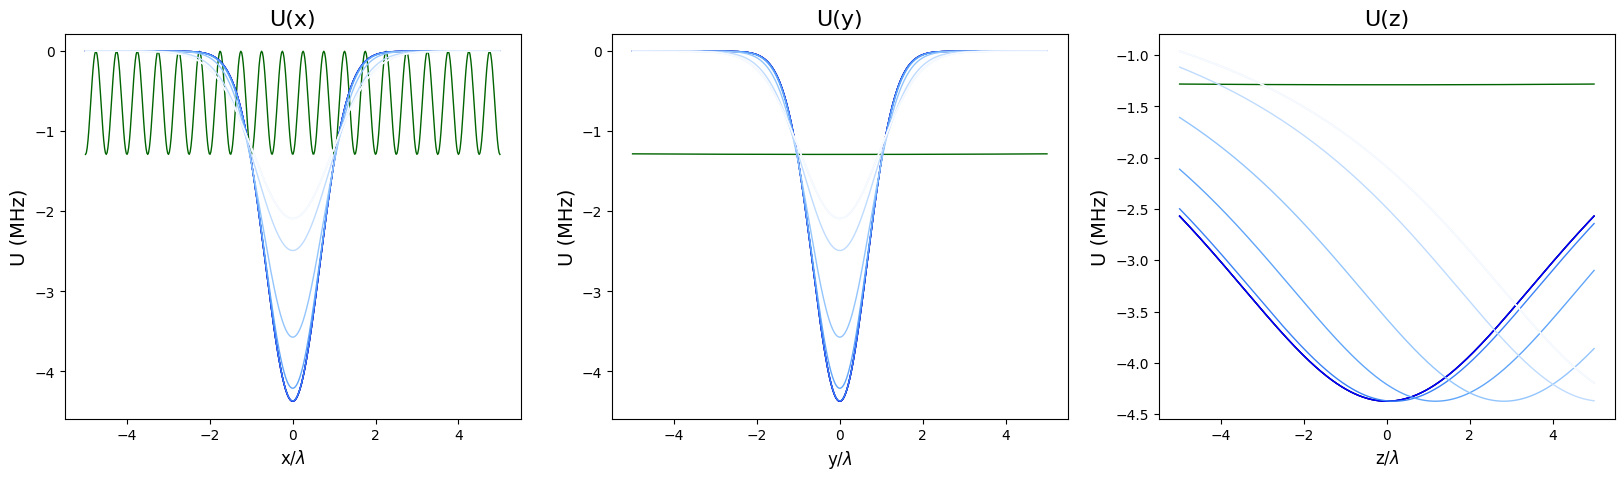

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))
plt.subplots_adjust(wspace=0.2)

#Lattice
axes[0].plot(x/wavelength_lat, J_to_Hz(U_L_x)*1e-6, color='darkgreen', linewidth=1, markersize = 1)
axes[1].plot(y/wavelength_lat, J_to_Hz(U_L_y)*1e-6, color='darkgreen', linewidth=1, markersize = 1)
axes[2].plot(z/wavelength_lat, J_to_Hz(U_L_z)*1e-6, color='darkgreen', linewidth=1, markersize = 1)

#Tweezers
for i in range(len(U_T_x)):
    axes[0].plot(x/wavelength_lat, J_to_Hz(U_T_x[i])*1e-6, color=colours[i], linewidth=1, markersize = 1)
    axes[1].plot(y/wavelength_lat, J_to_Hz(U_T_y[i])*1e-6, color=colours[i], linewidth=1, markersize = 1)
    axes[2].plot(z/wavelength_lat, J_to_Hz(U_T_z[i])*1e-6, color=colours[i], linewidth=1, markersize = 1)

axes[0].set_title('U(x)', fontsize=16)
axes[0].set_xlabel(r'x/$\lambda$', fontsize=12)
axes[0].set_ylabel(r'U (MHz)', fontsize=14)  
axes[1].set_title('U(y)', fontsize=16)
axes[1].set_xlabel(r'y/$\lambda$', fontsize=12)
axes[1].set_ylabel(r'U (MHz)', fontsize=14)  
axes[2].set_title('U(z)', fontsize=16)
axes[2].set_xlabel(r'z/$\lambda$', fontsize=12)
axes[2].set_ylabel(r'U (MHz)', fontsize=14)
#for i in range(3):
    #axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

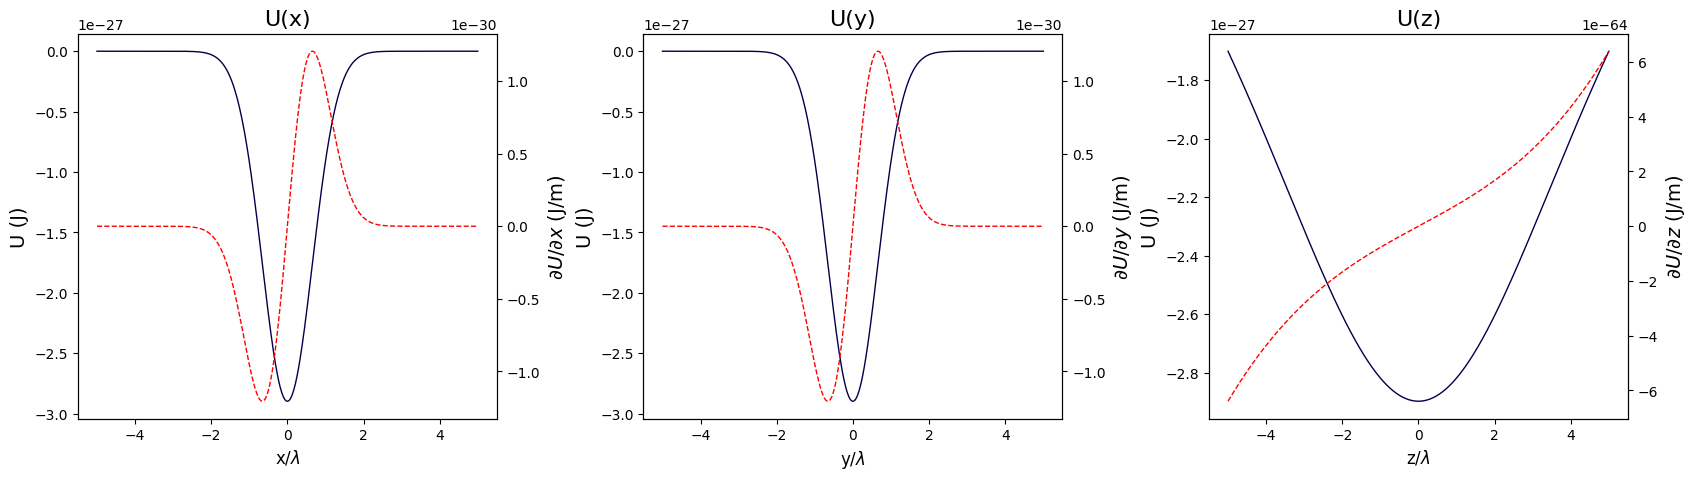

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))
plt.subplots_adjust(wspace=0.35)

#Tweezers
i = 0
ax0 = axes[0].twinx()
ax1 = axes[1].twinx()
ax2 = axes[2].twinx()

axes[0].plot(x/wavelength_lat, U_T_x[i], color=colours[i], linewidth=1, markersize = 1)
axes[1].plot(y/wavelength_lat, U_T_y[i], color=colours[i], linewidth=1, markersize = 1)
axes[2].plot(z/wavelength_lat, U_T_z[i], color=colours[i], linewidth=1, markersize = 1)

ax0.plot(x/wavelength_lat, grad_U_T_x[i][0], color='red', linewidth=1, markersize = 1, linestyle = '--')
ax1.plot(y/wavelength_lat, grad_U_T_y[i][1], color='red', linewidth=1, markersize = 1, linestyle = '--')
ax2.plot(z/wavelength_lat, grad_U_T_z[i][2], color='red', linewidth=1, markersize = 1, linestyle = '--')

axes[0].set_title('U(x)', fontsize=16)
axes[0].set_xlabel(r'x/$\lambda$', fontsize=12)
axes[0].set_ylabel(r'U (J)', fontsize=14)
ax0.set_ylabel(r'$\partial U / \partial x$ (J/m)', fontsize=14)  
axes[1].set_title('U(y)', fontsize=16)
axes[1].set_xlabel(r'y/$\lambda$', fontsize=12)
axes[1].set_ylabel(r'U (J)', fontsize=14)  
ax1.set_ylabel(r'$\partial U / \partial y$ (J/m)', fontsize=14)
axes[2].set_title('U(z)', fontsize=16)
axes[2].set_xlabel(r'z/$\lambda$', fontsize=12)
axes[2].set_ylabel(r'U (J)', fontsize=14)
ax2.set_ylabel(r'$\partial U / \partial z$ (J/m)', fontsize=14)
#for i in range(3):
    #axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

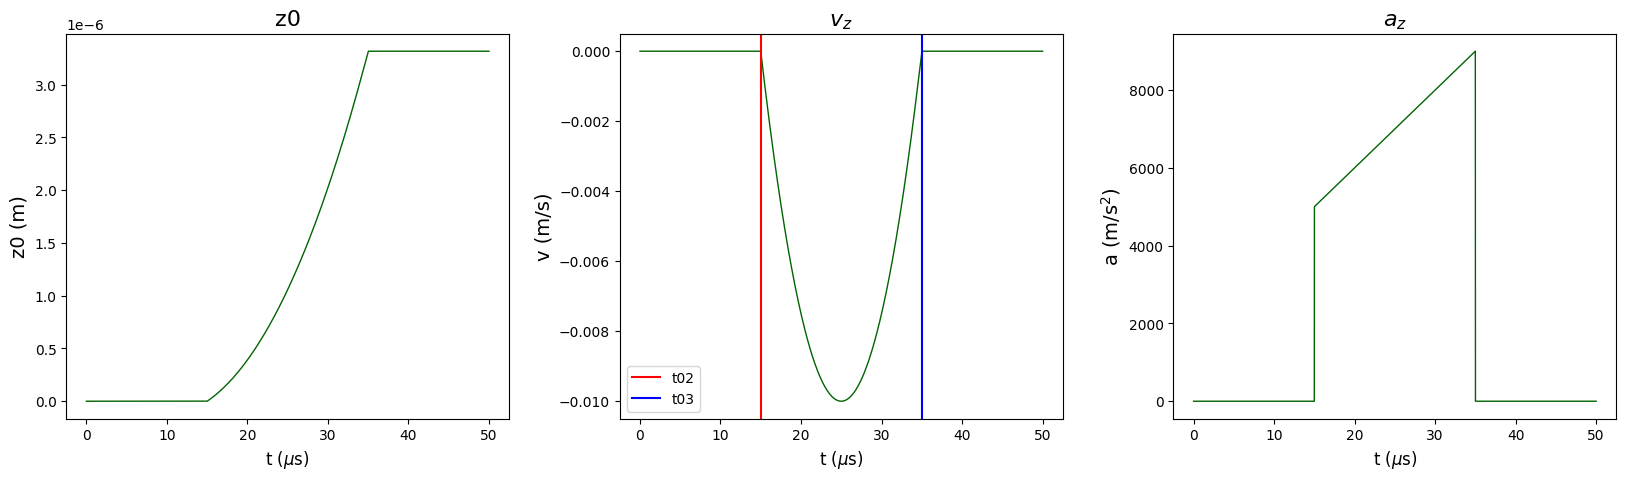

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))
plt.subplots_adjust(wspace=0.25)

#Lattice
axes[0].plot(t_eval*1e6, z0_t, color='darkgreen', linewidth=1, markersize = 1)

axes[1].plot(t_eval*1e6, v_t, color='darkgreen', linewidth=1, markersize = 1)

axes[1].axvline(x = t02*1e6, label = 't02', color = 'r')
axes[1].axvline(x = t03*1e6, label = 't03', color = 'b')

#axes[1].set_xlim(t03*1e6, t04*1e6)
#axes[1].set_ylim(-0.01, 0.02)

axes[2].plot(t_eval*1e6, a_t, color='darkgreen', linewidth=1, markersize = 1)


axes[0].set_title('z0', fontsize=16)
axes[0].set_xlabel(r't ($\mu$s)', fontsize=12)
axes[0].set_ylabel(r'z0 (m)', fontsize=14)  

axes[1].set_title(r'$v_z$', fontsize=16)
axes[1].set_xlabel(r't ($\mu$s)', fontsize=12)
axes[1].set_ylabel(r'v (m/s)', fontsize=14)

axes[2].set_title(r'$a_z$', fontsize=16)
axes[2].set_xlabel(r't ($\mu$s)', fontsize=12)
axes[2].set_ylabel(r'a (m/s$^2$)', fontsize=14)

axes[1].legend()#(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.show()

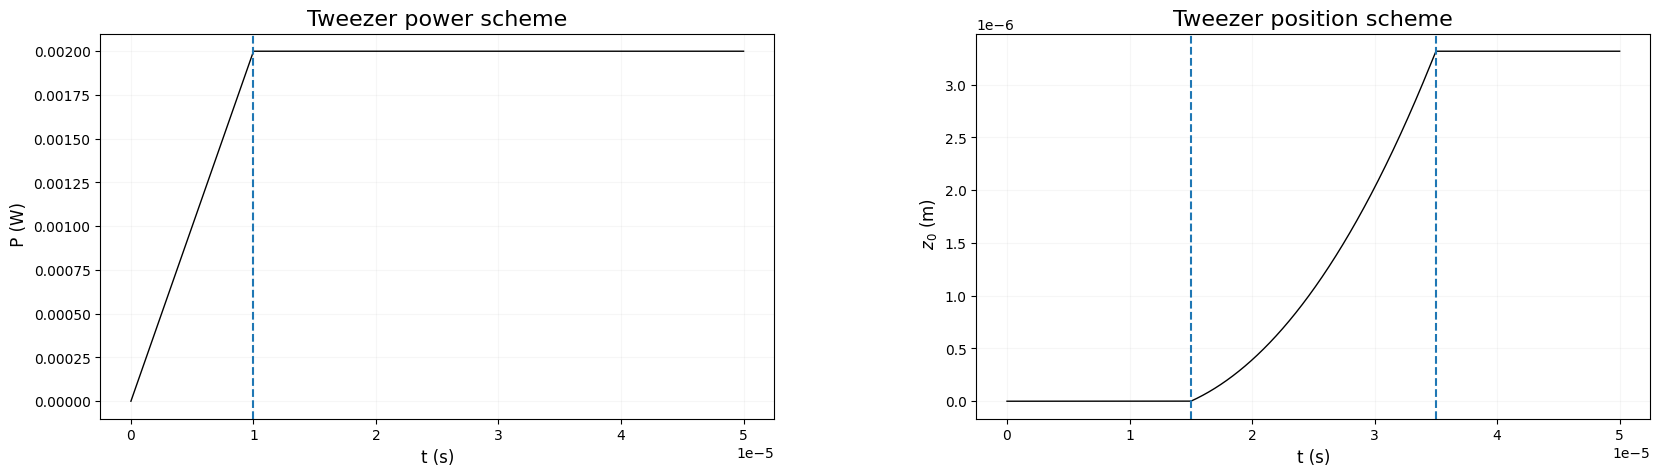

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(20,5))
fig.subplots_adjust(wspace=0.3)

axes[0].plot(t_eval, P_t, color='black', linewidth=1, markersize = 1)
axes[0].axvline(x = t01, linestyle = '--')

axes[0].set_title('Tweezer power scheme', fontsize=16)
axes[0].set_xlabel(r't (s)', fontsize=12)
axes[0].set_ylabel(r' P (W)', fontsize=12)
#axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.1)

axes[1].plot(t_eval, z0_t, color='black', linewidth=1, markersize = 1)
axes[1].axvline(x = t02, linestyle = '--')
axes[1].axvline(x = t03, linestyle = '--')

axes[1].set_title('Tweezer position scheme', fontsize=16)
axes[1].set_xlabel(r't (s)', fontsize=12)
axes[1].set_ylabel(r' $z_0$ (m)', fontsize=12)
#axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes[1].grid(True, alpha=0.1)

plt.show()

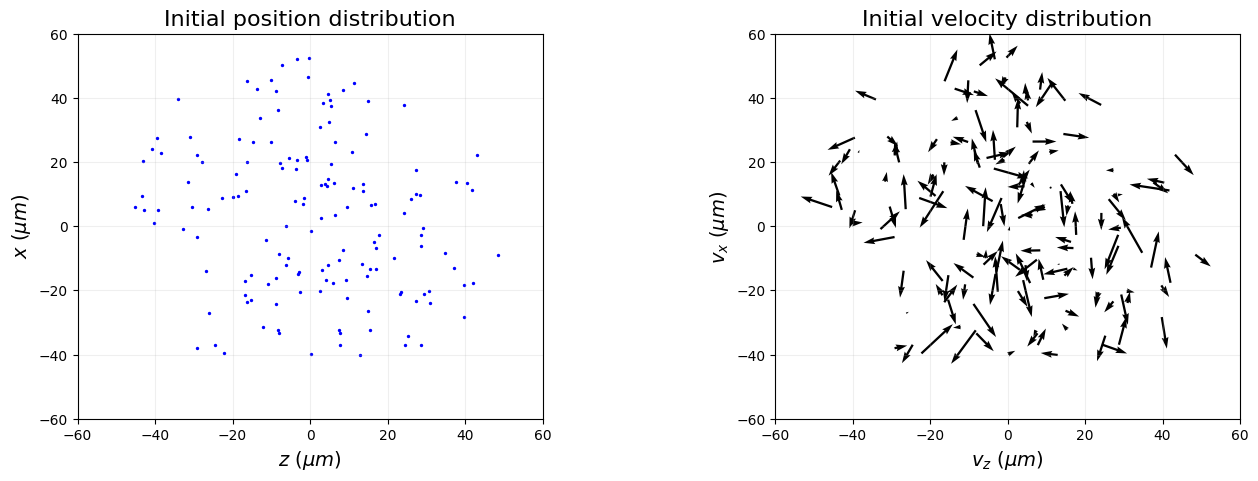

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

# ---- LEFT PLOT ----
ax = axes[0]
#ax3 = ax.twiny()
ax.scatter(init_pos[:,2]*1e6, init_pos[:,0]*1e6, s=2, color='b')

#ax3.plot((U_x_0_0_latt)/latt_depth_x, x*1e6, color='black', linewidth=1, label='Potential')

#ax3.set_xlabel(r'$U/U_{latt}$', fontsize=14)
#ax3.set_ylim()


ax.set_xlim(-60,60)
ax.set_ylim(-60,60)
ax.set_xlabel(r'$z$ ($\mu m$)', fontsize=14)
ax.set_ylabel(r'$x$ ($\mu m$)', fontsize=14)
ax.set_title('Initial position distribution', fontsize=16)
ax.grid(True, alpha=0.2)


# ---- RIGHT PLOT (example: histogram of x positions) ----
ax2 = axes[1]


ax2.quiver(init_pos[:,2]*1e6, init_pos[:,0]*1e6, init_vel[:,2]*1e6, init_vel[:,0]*1e6, angles='xy', scale_units='xy')


ax2.set_xlim(-60, 60)
ax2.set_ylim(-60, 60)
ax2.set_xlabel(r'$v_z$ ($\mu m$)', fontsize=14)
ax2.set_ylabel(r'$v_x$ ($\mu m$)', fontsize=14)
ax2.set_title('Initial velocity distribution', fontsize=16)
ax2.grid(True, alpha=0.2)

fig.subplots_adjust(wspace=0.5)   # <-- adjust this value
plt.show()

In [40]:
t, vels_overtime, pos_overtime, idx_lost_atoms, energies = atom_loading_lattice_tw(max_t, t_points, N_atoms, init_pos, init_vel, Re_alpha_lat, Re_alpha_tw, P_lat, P_tw, w01, w02, w0, 
                                                                                                      wavelength_lat, wavelength_tw, v_max, t_v_max, t01, t02, t03, x01=0, x02=0, z0=0)

  0%|          | 0/75 [00:00<?, ?it/s]

100%|██████████| 75/75 [00:08<00:00,  8.60it/s]


In [41]:
vx, vy, vz = vels_overtime[:, 0, :], vels_overtime[:, 1, :], vels_overtime[:, 2, :]
x, y, z = pos_overtime[:, 0, :], pos_overtime[:, 1, :], pos_overtime[:, 2, :]
print('Number of lost atoms:', len(idx_lost_atoms))
print('Trapped atoms in tweezers:', (N_atoms-len(idx_lost_atoms))/N_atoms)

Number of lost atoms: 37
Trapped atoms in tweezers: 0.5066666666666667


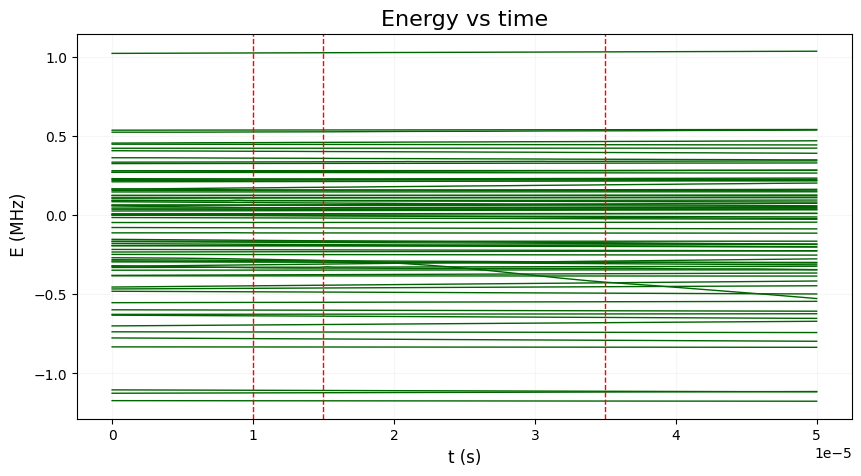

In [42]:
fig, axes = plt.subplots(1, 1, figsize=(10,5))
fig.subplots_adjust(wspace=0.3)
for i in range(N_atoms):
    axes.plot(t, J_to_Hz(energies[i])*1e-6, color='darkgreen', linewidth=1, markersize = 1)
axes.axvline(t01, color='red', linestyle='--', linewidth = 1)
axes.axvline(t02, color='red', linestyle='--', linewidth = 1)
axes.axvline(t03, color='red', linestyle='--', linewidth = 1)
#axes.axvline(t_eval[1], color='red', linestyle='--', label='step size', linewidth = 1)
axes.set_title('Energy vs time', fontsize=16)
axes.set_xlabel(r't (s)', fontsize=12)
axes.set_ylabel(r' E (MHz)', fontsize=12)
#axes.set_xlim(-1e-3, 0.002)
#axes.set_ylim(-1, 0.5)
#axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes.grid(True, alpha=0.1)


plt.show()

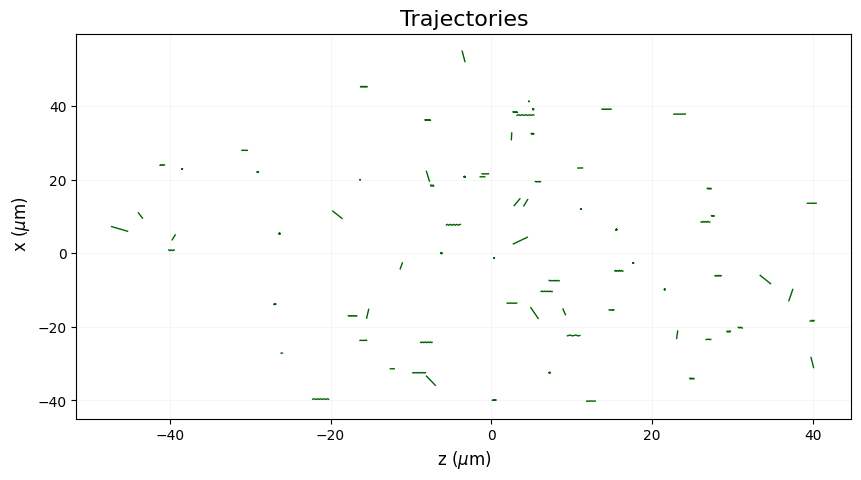

In [43]:
fig, axes = plt.subplots(1, 1, figsize=(10,5))
fig.subplots_adjust(wspace=0.3)
for i in range(N_atoms):
    axes.plot(z[i]*1e6, x[i]*1e6, color='darkgreen', linewidth=1, markersize = 1)

axes.set_title('Trajectories', fontsize=16)
axes.set_xlabel(r'z ($\mu$m)', fontsize=12)
axes.set_ylabel(r' x ($\mu$m)', fontsize=12)
#axes.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
axes.grid(True, alpha=0.1)

plt.show()